In [ ]:
# Import key libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pingouin as pg
from scipy import stats

In [ ]:
# Initialise the plotting style and data preprocessing functions

def _standardize_rt_acc(df):
    df = df.copy()
    df['rt'] = pd.to_numeric(df['rt'], errors='coerce')
    df['acc'] = pd.to_numeric(df['acc'], errors='coerce')
    if df['rt'].notna().any() and df['rt'].max() <= 50:
        df['rt'] = df['rt'] * 1000
    if df['acc'].notna().any() and df['acc'].max() <= 1.5:
        df['acc'] = df['acc'] * 100
    return df

def build_pre_matched_plot_df(source_df):
    df = source_df.copy()
    df['rt'] = pd.to_numeric(df['rt'], errors='coerce')
    df['bin_acc'] = pd.to_numeric(df['bin_acc'], errors='coerce')
    df['task_type'] = df['task_type'].astype(str).str.upper()

    sjt_df = df[df['task_type'].str.contains('SJT', na=False)].copy()
    vgt_df = df[df['task_type'].str.contains('VSG', na=False)].copy()

    def trial_summary(task_df, task_label):
        grouped = task_df.groupby('trial_id', as_index=False).agg(
            rt=('rt', 'mean'),
            acc=('bin_acc', 'mean'),
            n_responses=('bin_acc', lambda x: x.notna().sum()),
            std_rt=('rt', 'std'),
            std_acc=('bin_acc', 'std'),
        )
        grouped['task'] = task_label
        grouped = _standardize_rt_acc(grouped)
        return grouped[["rt", "acc", "task", "trial_id", "n_responses", "std_rt", "std_acc"]]

    sjt_plot = trial_summary(sjt_df, 'Words')
    vgt_plot = trial_summary(vgt_df, 'Grids')

    plot_df = pd.concat([sjt_plot, vgt_plot], ignore_index=True, sort=False)
    plot_df = plot_df.dropna(subset=['rt', 'acc']).reset_index(drop=True)
    return plot_df

def build_post_matched_plot_df(source_df):
    df = source_df.copy()
    words = pd.DataFrame({
        'rt': pd.to_numeric(df['prt'], errors='coerce'),
        'acc': pd.to_numeric(df['pacc'], errors='coerce'),
        'task': 'Words',
    })
    grids = pd.DataFrame({
        'rt': pd.to_numeric(df['grt'], errors='coerce'),
        'acc': pd.to_numeric(df['gacc'], errors='coerce'),
        'task': 'Grids',
    })

    plot_df = pd.concat([words, grids], ignore_index=True)
    plot_df = plot_df.dropna(subset=['rt', 'acc']).reset_index(drop=True)
    plot_df = _standardize_rt_acc(plot_df)
    return plot_df

def plot_rt_accuracy(plot_df, title, output_path, xlim=None):
    sns.set(style='white')

    fig = plt.figure(figsize=PLOT_STYLE['figsize'], dpi=PLOT_STYLE['dpi'])
    left = PLOT_STYLE['left']
    bottom = PLOT_STYLE['bottom']
    width = PLOT_STYLE['width']
    height = PLOT_STYLE['height']
    spacing = PLOT_STYLE['spacing']

    ax = fig.add_axes([left, bottom, width, height])
    top_ax = fig.add_axes([left, bottom + height + spacing, width, 0.18])
    right_ax = fig.add_axes([left + width + spacing, bottom, 0.18, height])

    for task, grp in plot_df.groupby('task'):
        color = PLOT_STYLE['color_map'][task]
        ax.scatter(grp['rt'], grp['acc'], s=18, color=color, alpha=0.6, edgecolors='none', label=task, zorder=3)

    ax.set_ylim(0, 100)
    if xlim is None:
        xlim = (plot_df['rt'].min(), plot_df['rt'].max())
    ax.set_xlim(*xlim)

    rt_min, rt_max = xlim
    for task, grp in plot_df.groupby('task'):
        color = PLOT_STYLE['color_map'][task]
        mean_rt = grp['rt'].mean()
        mean_acc = grp['acc'].mean()
        ax.hlines(mean_acc, rt_min, rt_max, colors=color, linewidth=1.6, alpha=0.9, zorder=2)
        ax.vlines(mean_rt, ymin=0, ymax=100, colors=color, linewidth=1.0, linestyles=':', alpha=0.9, zorder=1)
        ax.scatter([mean_rt], [mean_acc], s=30, color=color, edgecolors='k', linewidths=0.6, zorder=6)

    ax.set_xlabel('Response Time (ms)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)

    ax.grid(False)
    for y in ax.get_yticks():
        ax.axhline(y=y, color='grey', linewidth=0.5, linestyle='--', alpha=0.18, zorder=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_linewidth(0.8)

    for task in ['Words', 'Grids']:
        subset = plot_df[plot_df['task'] == task]
        color = PLOT_STYLE['color_map'][task]
        if subset.shape[0] < 2:
            top_ax.hist(subset['rt'].dropna(), bins=6, color=color, alpha=0.6)
            right_ax.hist(subset['acc'].dropna(), bins=6, orientation='horizontal', color=color, alpha=0.6)
        else:
            sns.kdeplot(data=subset, x='rt', ax=top_ax, fill=True, color=color, alpha=PLOT_STYLE['kde_alpha'], linewidth=0, bw_adjust=1)
            sns.kdeplot(data=subset, y='acc', ax=right_ax, fill=True, color=color, alpha=PLOT_STYLE['kde_alpha'], linewidth=0, bw_adjust=1)

    for marg_ax in (top_ax, right_ax):
        marg_ax.set_xticks([])
        marg_ax.set_yticks([])
        marg_ax.set_xlabel('')
        marg_ax.set_ylabel('')
        marg_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in marg_ax.spines.values():
            spine.set_visible(False)
        marg_ax.patch.set_alpha(0.0)

    top_ax.set_xlim(ax.get_xlim())
    right_ax.set_ylim(ax.get_ylim())

    ax.legend(title='Trial Type')
    counts = plot_df.groupby('task').size()
    ax.text(
        0.98,
        0.02,
        f"Word trials: N={counts.get('Words', 0)}\nGrid trials: N={counts.get('Grids', 0)}",
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
    )

    plt.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
   # plt.show()
    print(f'Saved: {output_path}')
    return fig

PLOT_STYLE = {
    "figsize": (8, 6),
    "dpi": 150,
    "left": 0.12,
    "bottom": 0.12,
    "width": 0.62,
    "height": 0.62,
    "spacing": 0.02,
    "color_map": {
        "Words": (0.95, 0.55, 0.10),
        "Grids": (0.30, 0.60, 0.95)
    },
    "kde_alpha": 0.45,
}


   subject_id  trial_index trial_id    target      rt  rt_true  bin_acc  \
0           1            0   FOREST    JUNGLE  1618.0   1618.0        1   
1           1            1   SINGLE     ALONE  1769.0   1769.0        1   
2           1            2     CITY      TOWN  1223.0   1223.0        1   
3           1            3  RESPITE  CONTEMPT  2691.0      NaN        0   
4           1            4     NEAR      MOVE  1911.0   1911.0        1   

  task_type Unnamed: 8  
0       SJT        NaN  
1       SJT        NaN  
2       SJT        NaN  
3       SJT        NaN  
4       SJT        NaN  


C:\Users\gb03\AppData\Local\Temp\ipykernel_10132\2413950188.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: pre-match_rt-accuracy.png


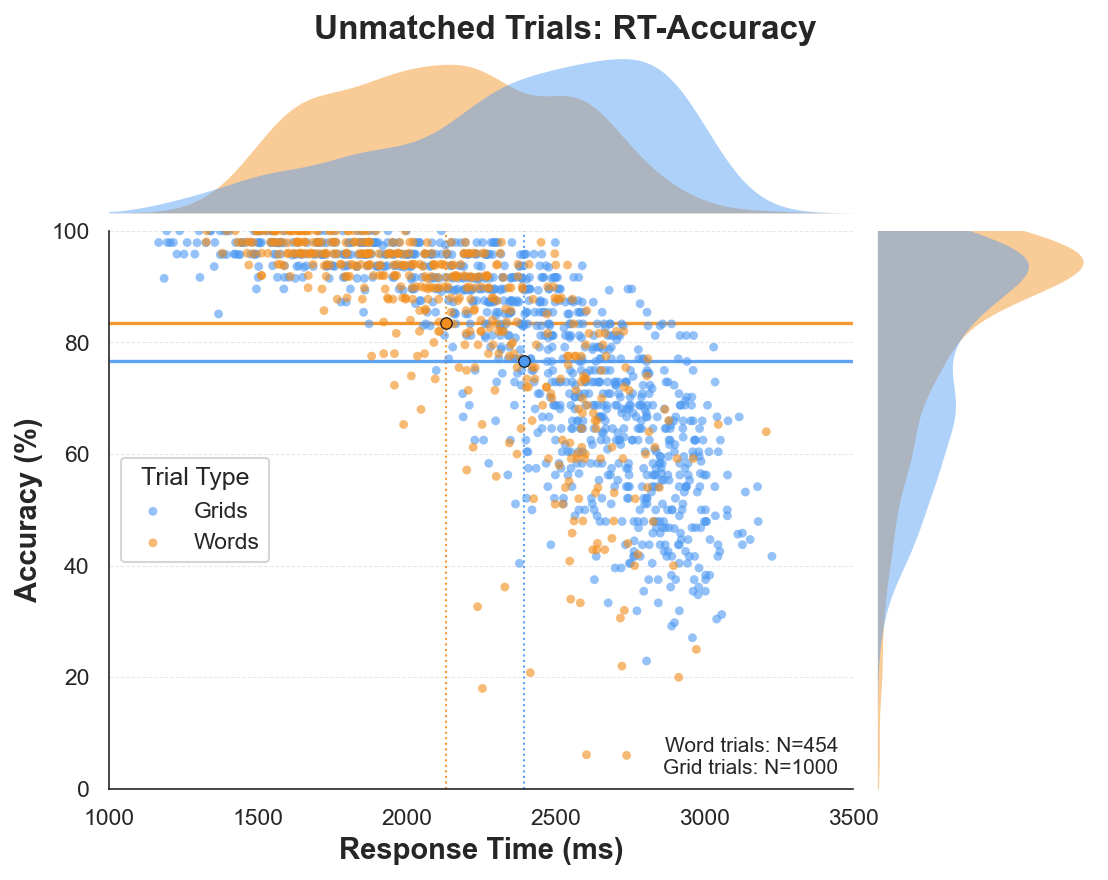

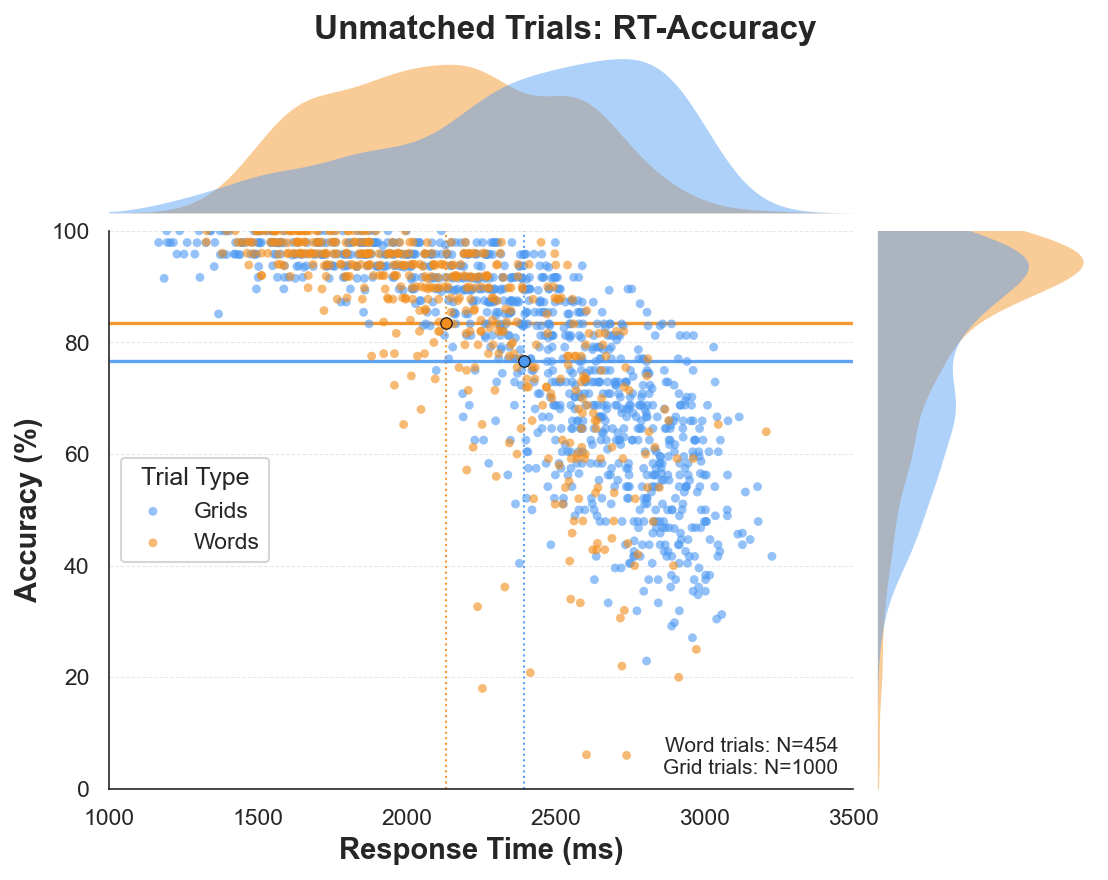

In [ ]:
# Load the pre-matched dataset and prepare the figure inputs
file_path = '/merged_task_data.csv' #change this to the local path where you have the merged_task_data.csv file saved
pre_source = pd.read_csv(file_path, low_memory=False)
pre_plot_df = build_pre_matched_plot_df(pre_source)
print(f'Pre-matched points: {len(pre_plot_df)}')
plot_rt_accuracy(
    pre_plot_df,
    title="Unmatched Trials: RT-Accuracy",
    output_path="pre-match_rt-accuracy.png",
    xlim=(1000, 3500)
    )

Post-matched points: 820


C:\Users\gb03\AppData\Local\Temp\ipykernel_10132\2413950188.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: post_match_rt_accuracy.png


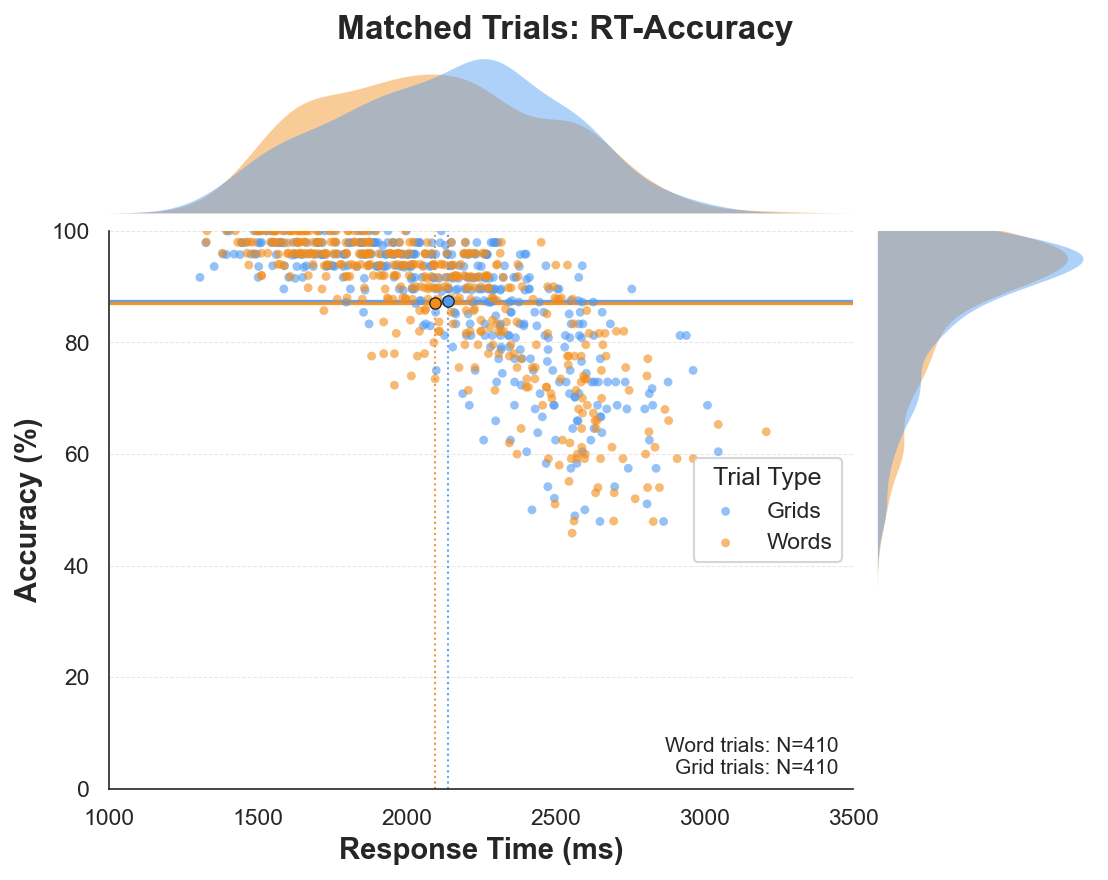

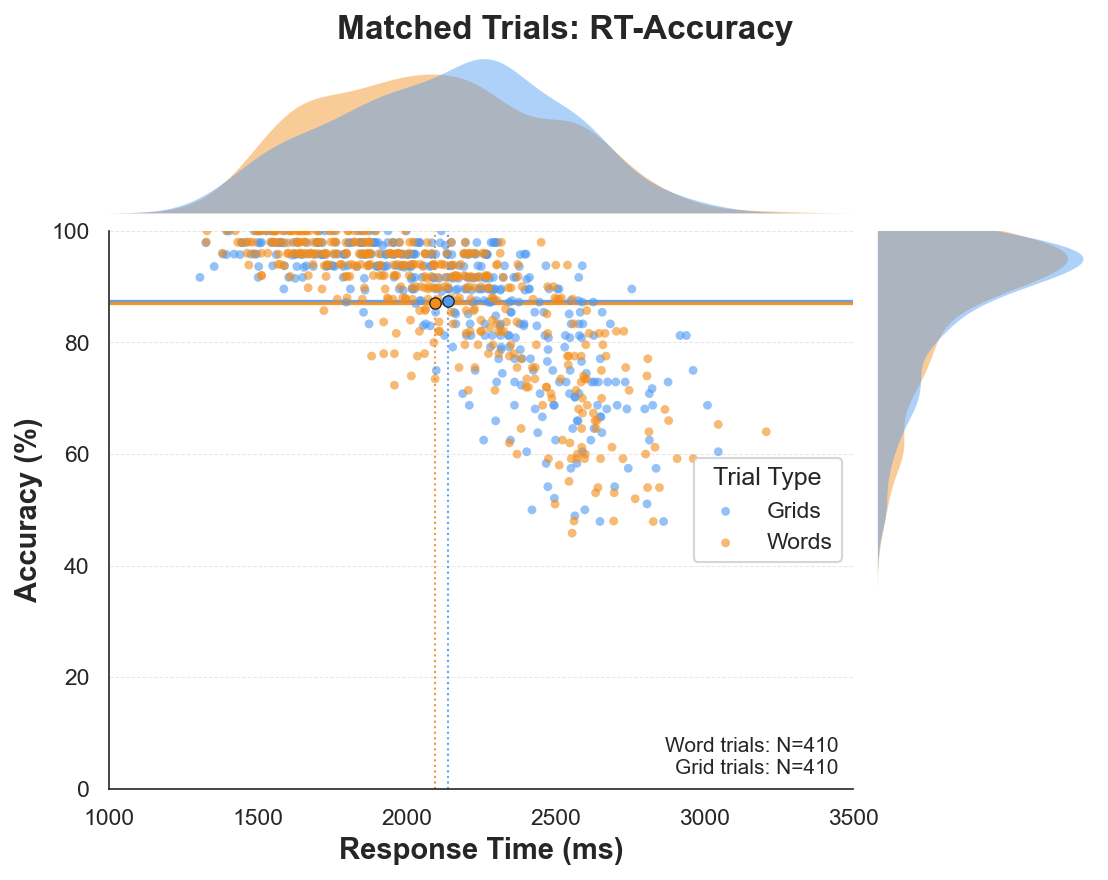

In [ ]:
# Load the post-matched dataset and prepare the figure inputs
post_source = pd.read_excel('/matched_trials.xlsx') #change this to the local path where you have the matched_trials.xlsx file saved
post_plot_df = build_post_matched_plot_df(post_source)
print(f'Post-matched points: {len(post_plot_df)}')
plot_rt_accuracy(
    post_plot_df,
    "Matched Trials: RT-Accuracy",
    "post_match_rt_accuracy.png",
    xlim=(1000, 3500)
)

In [ ]:
# Run Bayesian group comparison for pre-matched and post-matched datasets
def _coerce_bf10(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).strip().replace(",", "")
    if text.startswith(">"):
        text = text[1:]
    elif text.startswith("<"):
        text = text[1:]

    try:
        return float(text)
    except ValueError:
        return np.nan

def _posterior_variance_ratio(x, y, draws=50000, seed=42):
    x = pd.Series(x).dropna().to_numpy(dtype=float)
    y = pd.Series(y).dropna().to_numpy(dtype=float)

    if len(x) < 2 or len(y) < 2:
        raise ValueError("Each group must have at least two observations for variance comparison.")

    x_shape = (len(x) - 1) / 2
    y_shape = (len(y) - 1) / 2
    x_scale = (len(x) - 1) * np.var(x, ddof=1) / 2
    y_scale = (len(y) - 1) * np.var(y, ddof=1) / 2

    rng = np.random.default_rng(seed)
    x_var = stats.invgamma(a=x_shape, scale=x_scale).rvs(size=draws, random_state=rng)
    y_var = stats.invgamma(a=y_shape, scale=y_scale).rvs(size=draws, random_state=rng)
    ratio = x_var / y_var

    return {
        "median_ratio": float(np.median(ratio)),
        "ci_low": float(np.quantile(ratio, 0.025)),
        "ci_high": float(np.quantile(ratio, 0.975)),
        "prob_ratio_gt_1": float(np.mean(ratio > 1)),
        "prob_ratio_lt_1": float(np.mean(ratio < 1)),
    }

def run_bayesian_group_comparison(plot_df, dataset_label):
    words = plot_df[plot_df["task"] == "Words"].copy()
    grids = plot_df[plot_df["task"] == "Grids"].copy()

    print(f"\n=== {dataset_label} Bayesian comparison ===")
    print(f"Words: n={len(words)} | Grids: n={len(grids)}")

    mean_rows = []
    for measure, label in [("rt", "Reaction Time (ms)"), ("acc", "Accuracy (%)")]:
        test_result = pg.ttest(words[measure], grids[measure], paired=False)
        test_row = test_result.iloc[0]
        bf10 = _coerce_bf10(test_row["BF10"])

        mean_rows.append(
            {
                "Measure": label,
                "Words_Mean": words[measure].mean(),
                "Grids_Mean": grids[measure].mean(),
                "Mean_Difference": words[measure].mean() - grids[measure].mean(),
                "BF10": bf10,
                "t": test_row["T"],
                "p": test_row["p-val"],
                "d": test_row["cohen-d"],
            }
        )

    mean_df = pd.DataFrame(mean_rows)
    print("\nMean comparison (Bayesian independent t-tests):")
    print(mean_df)

    rt_var = _posterior_variance_ratio(words["rt"], grids["rt"])
    acc_var = _posterior_variance_ratio(words["acc"], grids["acc"])

    variability_df = pd.DataFrame(
        [
            {
                "Measure": "Reaction Time (ms)",
                **rt_var,
            },
            {
                "Measure": "Accuracy (%)",
                **acc_var,
            },
        ]
    )

    print("\nVariability comparison (posterior variance ratio):")
    print(variability_df)

    return mean_df, variability_df

pre_mean_df, pre_variability_df = run_bayesian_group_comparison(pre_plot_df, "Pre-matched")
post_mean_df, post_variability_df = run_bayesian_group_comparison(post_plot_df, "Post-matched")



=== Pre-matched Bayesian comparison ===
Words: n=21886 | Grids: n=45954

Mean comparison (Bayesian independent t-tests):
              Measure   Words_Mean   Grids_Mean  Mean_Difference  \
0  Reaction Time (ms)  2127.265421  2384.008095      -256.742674   
1        Accuracy (%)    85.319382    79.477303         5.842079   

           BF10          t             p         d  
0           inf -38.514701  0.000000e+00  0.309068  
1  4.525000e+77  19.185051  9.915212e-82  0.150391  

Variability comparison (posterior variance ratio):
              Measure  median_ratio    ci_low   ci_high  prob_ratio_gt_1  \
0  Reaction Time (ms)      0.877345  0.857459  0.897533              0.0   
1        Accuracy (%)      0.767959  0.750553  0.785630              0.0   

   prob_ratio_lt_1  
0              1.0  
1              1.0  

=== Post-matched Bayesian comparison ===
Words: n=410 | Grids: n=410

Mean comparison (Bayesian independent t-tests):
              Measure   Words_Mean   Grids_Mean  Me

C:\Users\gb03\AppData\Roaming\Python\Python39\site-packages\pingouin\bayesian.py:154: RuntimeWarning: overflow encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)



Variability comparison (posterior variance ratio):
              Measure  median_ratio    ci_low   ci_high  prob_ratio_gt_1  \
0  Reaction Time (ms)      1.046853  0.860526  1.271271          0.67794   
1        Accuracy (%)      1.139780  0.936912  1.384119          0.90746   

   prob_ratio_lt_1  
0          0.32206  
1          0.09254  
